In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential
from keras.losses import CategoricalCrossentropy
from keras.utils import to_categorical
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

np.random.seed(6)
tf.random.set_seed(6)
tf.compat.v1.set_random_seed(6)

In [2]:
images = np.load("./images.npy")
labels = np.load("./labels.npy")
images = images / 255
# print(images.shape) # 18000 75 75
# print(labels.shape)  # 18000 2
labels_df = pd.DataFrame([f"({hour:02d}, {minutes:02d})" for hour, minutes in labels], columns=["time"])

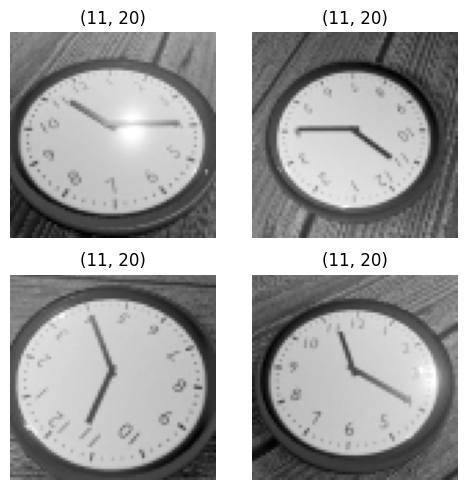

In [3]:
num_images_to_plot = 4
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i+17000], cmap='gray')  # Assuming images are grayscale
    ax.set_title(labels_df["time"][i+17000])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Classification

In [4]:
categories24 = []
for hour, minutes in labels:
    if 0 <= minutes <= 30:
        categories24.append(f"{hour:02d}:00 - {hour:02d}:30")
    elif 30 < minutes < 60:
        if hour < 23:
            categories24.append(f"{hour:02d}:30 - {hour + 1:02d}:00")
        else:
            categories24.append(f"{hour:02d}:30 - 00:00")

labels_df["categories24"] = categories24


label_to_int = {label: idx for idx, label in enumerate(sorted(set(categories24)))}
int_labels = [label_to_int[label] for label in categories24]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, int_labels, test_size=0.2, random_state=42)

In [12]:
X_train.shape

(14400, 75, 75)

In [14]:
keras.utils.to_categorical(y_train, num_classes=len(label_to_int)).shape

(14400, 24)

Epoch 1/500
180/180 [==============================] - 15s 40ms/step - loss: 3.1912 - accuracy: 0.0535 - val_loss: 2.9020 - val_accuracy: 0.1128
Epoch 2/500
180/180 [==============================] - 6s 35ms/step - loss: 2.5150 - accuracy: 0.1723 - val_loss: 2.6810 - val_accuracy: 0.1215
Epoch 3/500
180/180 [==============================] - 6s 33ms/step - loss: 2.0413 - accuracy: 0.2713 - val_loss: 3.1850 - val_accuracy: 0.1625
Epoch 4/500
180/180 [==============================] - 6s 34ms/step - loss: 1.6315 - accuracy: 0.4034 - val_loss: 1.5354 - val_accuracy: 0.4667
Epoch 5/500
180/180 [==============================] - 6s 35ms/step - loss: 1.2700 - accuracy: 0.5183 - val_loss: 1.1993 - val_accuracy: 0.5486
Epoch 6/500
180/180 [==============================] - 6s 35ms/step - loss: 1.0203 - accuracy: 0.6056 - val_loss: 1.8742 - val_accuracy: 0.3896
Epoch 7/500
180/180 [==============================] - 6s 33ms/step - loss: 0.8533 - accuracy: 0.6797 - val_loss: 1.5024 - val_accuracy

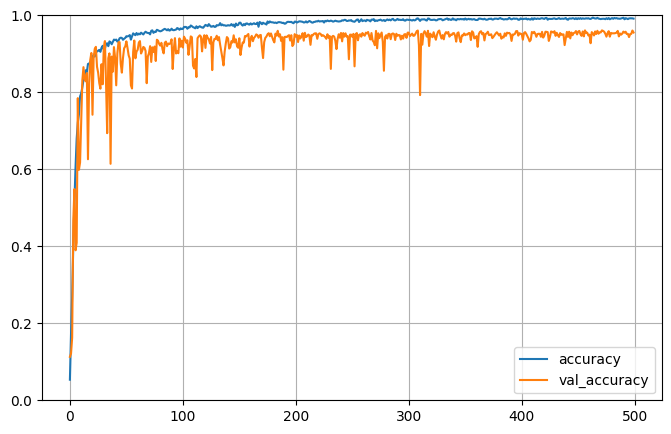

In [ ]:
model24 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', input_shape=(75, 75, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.BatchNormalization(momentum =0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(24, activation='softmax')
])

# Compile the model
model24.compile(loss='categorical_crossentropy', optimizer = "adam", metrics=['accuracy'])

history24 = model24.fit(X_train, keras.utils.to_categorical(y_train, num_classes=len(label_to_int)), epochs=500,
                        batch_size=64, validation_split=0.2)

classification_test_accuracy24 = model24.evaluate(X_test, keras.utils.to_categorical(y_test, num_classes=len(label_to_int)))

pd.DataFrame(history24.history)[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
categories72 = []
for hour, minutes in labels:
    if 0 <= minutes <= 10:
        categories72.append(f"{hour:02d}:00 - {hour:02d}:10")
    elif 10 < minutes <= 20:
        categories72.append(f"{hour:02d}:10 - {hour:02d}:20")
    elif 20 < minutes <= 30:
        categories72.append(f"{hour:02d}:20 - {hour:02d}:30")
    elif 30 < minutes <= 40:
        categories72.append(f"{hour:02d}:30 - {hour:02d}:40")
    elif 40 < minutes <= 50:
        categories72.append(f"{hour:02d}:40 - {hour:02d}:50")
    else:
        if hour < 23:
            categories72.append(f"{hour:02d}:50 - {hour + 1:02d}:00")
        else:
            categories72.append(f"{hour:02d}:50 - 00:00")

labels_df["categories72"] = categories72

label_to_int72 = {label: idx for idx, label in enumerate(sorted(set(categories72)))}
int_labels72 = [label_to_int72[label] for label in categories72]

# Split the data into training and testing sets
X_train72, X_test72, y_train72, y_test72 = train_test_split(images, int_labels72, test_size=0.2, random_state=42)

Epoch 1/500
180/180 [==============================] - 14s 36ms/step - loss: 4.3293 - accuracy: 0.0136 - val_loss: 4.2760 - val_accuracy: 0.0149
Epoch 2/500
180/180 [==============================] - 6s 33ms/step - loss: 4.2693 - accuracy: 0.0184 - val_loss: 4.2851 - val_accuracy: 0.0191
Epoch 3/500
180/180 [==============================] - 6s 32ms/step - loss: 3.8052 - accuracy: 0.0624 - val_loss: 5.3763 - val_accuracy: 0.0389
Epoch 4/500
180/180 [==============================] - 6s 34ms/step - loss: 2.9504 - accuracy: 0.1365 - val_loss: 2.4383 - val_accuracy: 0.2313
Epoch 5/500
180/180 [==============================] - 6s 34ms/step - loss: 2.4923 - accuracy: 0.2062 - val_loss: 2.0465 - val_accuracy: 0.2990
Epoch 6/500
180/180 [==============================] - 6s 33ms/step - loss: 2.1917 - accuracy: 0.2599 - val_loss: 1.8752 - val_accuracy: 0.3194
Epoch 7/500
180/180 [==============================] - 6s 32ms/step - loss: 1.9943 - accuracy: 0.3073 - val_loss: 1.6529 - val_accuracy

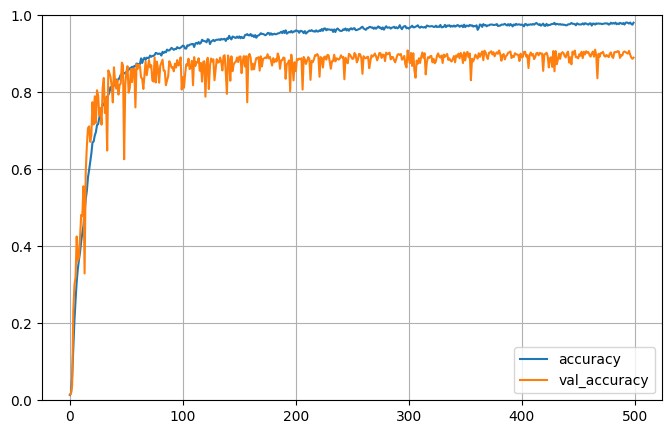

In [ ]:
model72 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', input_shape=(75, 75, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(momentum =0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(72, activation='softmax')
])

# Compile the model
model72.compile(loss='categorical_crossentropy', optimizer = "adam", metrics=['accuracy'])

history72 = model72.fit(X_train72, keras.utils.to_categorical(y_train72, num_classes=len(label_to_int72)), epochs=500,
                        batch_size=64,validation_split=0.2)

classification_test_accuracy72 = model72.evaluate(X_test72, keras.utils.to_categorical(y_test72, num_classes=len(label_to_int72)))

pd.DataFrame(history72.history)[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [4]:
label_to_int_720 = {label: idx for idx, label in enumerate(sorted(set(labels_df["time"])))}
int_labels_720 = [label_to_int_720[label] for label in labels_df["time"]]

# Split the data into training and testing sets
X_train_720, X_test_720, y_train_720, y_test_720 = train_test_split(images, int_labels_720, test_size=0.2, random_state=42)

Epoch 1/500
180/180 [==============================] - 21s 71ms/step - loss: 6.6144 - accuracy: 0.0011 - val_loss: 6.5811 - val_accuracy: 0.0014
Epoch 2/500
180/180 [==============================] - 12s 68ms/step - loss: 6.5917 - accuracy: 0.0022 - val_loss: 6.5812 - val_accuracy: 0.0017
Epoch 3/500
180/180 [==============================] - 12s 66ms/step - loss: 6.5863 - accuracy: 0.0015 - val_loss: 6.5820 - val_accuracy: 6.9444e-04
Epoch 4/500
180/180 [==============================] - 13s 71ms/step - loss: 6.5836 - accuracy: 0.0015 - val_loss: 6.5815 - val_accuracy: 3.4722e-04
Epoch 5/500
180/180 [==============================] - 12s 65ms/step - loss: 6.5801 - accuracy: 0.0016 - val_loss: 6.5819 - val_accuracy: 3.4722e-04
Epoch 6/500
180/180 [==============================] - 12s 69ms/step - loss: 6.5810 - accuracy: 0.0013 - val_loss: 6.5821 - val_accuracy: 3.4722e-04
Epoch 7/500
180/180 [==============================] - 12s 66ms/step - loss: 6.5816 - accuracy: 0.0016 - val_loss:

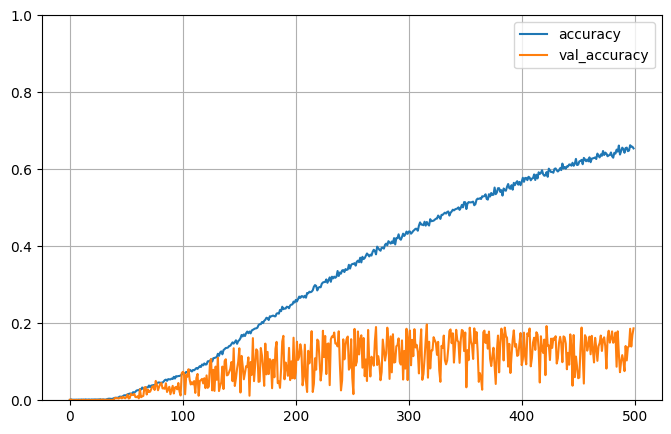

In [5]:
model_720 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', input_shape=(75, 75, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(momentum =0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(720, activation='softmax')
])


model_720.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

history720 = model_720.fit(X_train_720, keras.utils.to_categorical(y_train_720, num_classes=len(label_to_int_720)),
                           epochs=500, batch_size=64,validation_split=0.2)

classification_test_accuracy_720 = model_720.evaluate(X_test_720, keras.utils.to_categorical(y_test_720, num_classes=len(label_to_int_720)))

pd.DataFrame(history720.history)[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

# Regression

In [ ]:
regression_t = []

for hour, minutes in labels:
        regression_t.append(f"{hour+minutes/60}")

labels_df["regression_t"] = regression_t
labels_df["regression_t"] = pd.to_numeric(labels_df["regression_t"])

labels_regression=labels_df["regression_t"]

# Split the data into training and testing sets
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(images, labels_regression, test_size=0.2, random_state=42)

In [ ]:
y_train_regression = np.array(y_train_regression)
y_test_regression = np.array(y_test_regression)

model_regression1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', input_shape=(75, 75, 1)),
    tf.keras.layers.BatchNormalization(momentum=0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(momentum=0.9),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='linear')
])

model_regression1.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error')
# model_regression.compile(optimizer='adam',loss=tf.keras.losses.MeanSquaredError(),metrics=[tf.keras.metrics.RootMeanSquaredError()])

history_regression = model_regression1.fit(X_train_regression, y_train_regression, epochs=500, batch_size=64, verbose=1,validation_split=0.2)

mae = model_regression1.evaluate(X_test_regression, y_test_regression)
print("Mean Absolut Error:", mae)

Epoch 1/500
180/180 [==============================] - 24s 38ms/step - loss: 2.7769 - val_loss: 2.3473
Epoch 2/500
180/180 [==============================] - 6s 33ms/step - loss: 2.3603 - val_loss: 2.1190
Epoch 3/500
180/180 [==============================] - 6s 32ms/step - loss: 2.1317 - val_loss: 2.3495
Epoch 4/500
180/180 [==============================] - 6s 34ms/step - loss: 1.9196 - val_loss: 1.9885
Epoch 5/500
180/180 [==============================] - 6s 32ms/step - loss: 1.7467 - val_loss: 1.6103
Epoch 6/500
180/180 [==============================] - 6s 34ms/step - loss: 1.5766 - val_loss: 1.4267
Epoch 7/500
180/180 [==============================] - 6s 34ms/step - loss: 1.4394 - val_loss: 1.1798
Epoch 8/500
180/180 [==============================] - 6s 34ms/step - loss: 1.3294 - val_loss: 1.6556
Epoch 9/500
180/180 [==============================] - 6s 34ms/step - loss: 1.2297 - val_loss: 2.3303
Epoch 10/500
180/180 [==============================] - 6s 34ms/step - loss: 1.16

In [ ]:
y_pred_regression = model_regression1.predict(X_test_regression).flatten()

113/113 [==============================] - 1s 5ms/step


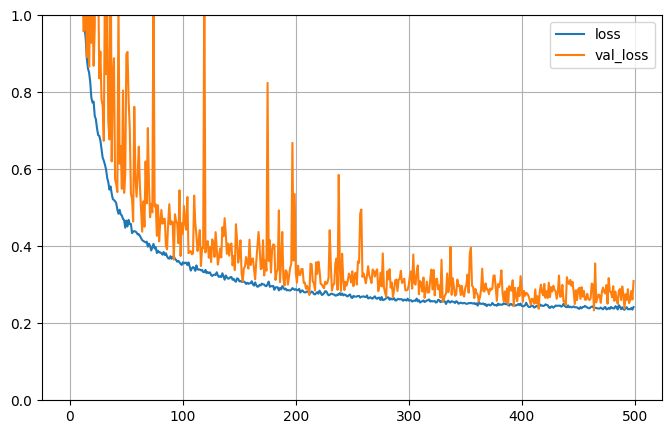

In [ ]:
pd.DataFrame(history_regression.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
def commons_sense_error(predicted, real):
  error_minutes=[]
  error_hours=[]
  overall_err=[]
  for i in range(len(real)):
    minutesp=(predicted[i]-int(predicted[i]))
    minutesr=(real[i]-int(real[i]))
    hourp=int(predicted[i])
    hourr=int(real[i])
    overall_err.append((min(abs(predicted[i]-real[i]),12-abs(predicted[i]-real[i]))*60))

    if hourp==hourr:
      error_minutes.append(abs(predicted[i]-real[i])*60)
      error_hours.append(0)
    elif hourr==11 and hourp==0:
      if (minutesp-minutesr)<-0.5: #only half hour difference
          error_minutes.append((minutesp-minutesr)*60+60)
          error_hours.append(0)
      else:
          error_hours.append(1)
          error_minutes.append(min(abs(minutesp-minutesr)*60,60-abs(minutesp-minutesr)*60))
    elif hourr==0 and hourp==11:
      if (minutesr-minutesp)<-0.5: #only half hour difference
          error_minutes.append((minutesr-minutesp)*60+60)
          error_hours.append(0)
      else:
          error_hours.append(1)
          error_minutes.append(min(abs(minutesp-minutesr)*60,60-abs(minutesp-minutesr)*60))
    else :
      if hourp>hourr:
        if (minutesp-minutesr)<-0.5: #only half hour difference
          error_minutes.append((minutesp-minutesr)*60+60)
          error_hours.append(hourp-hourr-1)
        else:
          error_hours.append(min(abs(hourp-hourr),12-abs(hourp-hourr)))
          error_minutes.append(min(abs(minutesp-minutesr)*60,60-abs(minutesp-minutesr)*60))
      else:
        if (minutesr-minutesp)<-0.5: #only half hour difference
          error_minutes.append((minutesr-minutesp)*60+60)
          error_hours.append(hourr-hourp-1)
        else:
          error_hours.append(min(abs(hourp-hourr),12-abs(hourp-hourr)))
          error_minutes.append(min(abs(minutesp-minutesr)*60,60-abs(minutesp-minutesr)*60))


  print(f'The common sense error calculated for the minutes pointer is {np.mean(error_minutes)}, for hour pointer is {np.mean(error_hours)} and for time (in minutes) is {np.mean(overall_err)}')

  return error_hours,error_minutes,overall_err

In [ ]:
(error_hours,error_minutes,error_overall)=commons_sense_error(y_pred_regression,y_test_regression)

The common sense error calculated for the minutes pointer is 11.265684941079881, for hour pointer is 0.10194444444444445 and for time (in minutes) is 15.614651224878099


# Multi-head

In [ ]:
hours_one_hot = tf.keras.utils.to_categorical(labels[:, 0], num_classes=12)  # 12 hours

X_train = images
hours_labels = hours_one_hot
labels_df['minutes']=[a-int(a) for a in labels_df['regression_t']]
minutes_labels = np.array(labels_df['minutes'])

images_train, images_test, hours_train, hours_test, minutes_train, minutes_test = train_test_split(
    images, hours_labels, minutes_labels, test_size=0.2, random_state=42
)



In [ ]:
input_shape = (75, 75, 1)
input_layer = Input(shape=input_shape)

conv1=tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(input_layer)
batch1=tf.keras.layers.BatchNormalization(momentum=0.9)(conv1)
pool1=tf.keras.layers.MaxPooling2D((2, 2))(batch1)
conv2=tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(batch1)
pool2=tf.keras.layers.MaxPooling2D((2, 2))(conv2)
conv3=tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(pool2)
pool3=tf.keras.layers.MaxPooling2D((2, 2))(conv3)
batch2=tf.keras.layers.BatchNormalization(momentum=0.9)(pool3)
pool4=tf.keras.layers.MaxPooling2D((2, 2))(batch2)
flatten=tf.keras.layers.Flatten()(pool4)

dense1=tf.keras.layers.Dense(1024, activation='relu')(flatten)
dropout1=tf.keras.layers.Dropout(0.4)(dense1)
dense2=tf.keras.layers.Dense(512, activation='relu')(dropout1)
dropout2=tf.keras.layers.Dropout(0.4)(dense2)

hours_output=tf.keras.layers.Dense(12, activation='softmax',name='hours_output')(dropout2)
minutes_output=tf.keras.layers.Dense(1, activation='linear', name='minutes_output')(dropout2)

model_multihead = Model(inputs=input_layer, outputs=[hours_output, minutes_output])



In [ ]:
model_multihead.compile(optimizer='adam',
                           loss={'hours_output': 'categorical_crossentropy', 'minutes_output': 'mean_absolute_error'},
                           metrics={'hours_output':'accuracy','minutes_output':'mean_absolute_error'})

# Fit the model
epochs = 300  # Define the number of epochs
batch_size = 64  # Define the batch size
history_multihead = model_multihead.fit(images_train, {'hours_output': hours_train, 'minutes_output': minutes_train},
                                 epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Evaluate the model on the test data
test_loss = model_multihead.evaluate(images_test, {'hours_output': hours_test, 'minutes_output': minutes_test})
print(f'Test Loss: {test_loss}')

Epoch 1/300
180/180 [==============================] - 13s 61ms/step - loss: 2.9878 - hours_output_loss: 2.5820 - minutes_output_loss: 0.4058 - hours_output_accuracy: 0.0850 - minutes_output_mean_absolute_error: 0.4058 - val_loss: 2.7673 - val_hours_output_loss: 2.4872 - val_minutes_output_loss: 0.2801 - val_hours_output_accuracy: 0.0858 - val_minutes_output_mean_absolute_error: 0.2801
Epoch 2/300
180/180 [==============================] - 11s 60ms/step - loss: 2.7679 - hours_output_loss: 2.4962 - minutes_output_loss: 0.2717 - hours_output_accuracy: 0.0826 - minutes_output_mean_absolute_error: 0.2717 - val_loss: 2.7538 - val_hours_output_loss: 2.4848 - val_minutes_output_loss: 0.2690 - val_hours_output_accuracy: 0.0833 - val_minutes_output_mean_absolute_error: 0.2690
Epoch 3/300
180/180 [==============================] - 11s 62ms/step - loss: 2.7411 - hours_output_loss: 2.4845 - minutes_output_loss: 0.2567 - hours_output_accuracy: 0.0885 - minutes_output_mean_absolute_error: 0.2567 - v

In [ ]:
predictions = model_multihead.predict(images_test)

hours_pred = np.argmax(predictions[0], axis=1)
minutes_pred=predictions[1].flatten()

hours_class_test = np.argmax(hours_test, axis=1)
minutes_test=minutes_test.flatten()

pred_time=hours_pred + minutes_pred
test_time=hours_class_test + minutes_test

113/113 [==============================] - 1s 8ms/step


In [ ]:
(error_hours_multihead,error_minutes_multihead,overall_error_multihead)=commons_sense_error(pred_time,test_time)

The common sense error calculated for the minutes pointer is 5.214418985760876, for hour pointer is 0.05416666666666667 and for time (in minutes) is 7.8453029923141


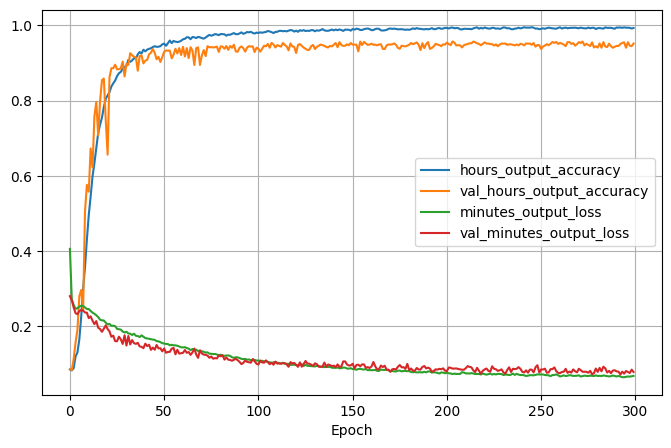

In [ ]:
hours_output_accuracy = history_multihead.history['hours_output_accuracy']
val_hours_output_accuracy = history_multihead.history['val_hours_output_accuracy']
minutes_output_loss = history_multihead.history['minutes_output_loss']
val_minutes_output_loss = history_multihead.history['val_minutes_output_loss']


history_df = pd.DataFrame({'hours_output_accuracy': hours_output_accuracy,
                           'val_hours_output_accuracy': val_hours_output_accuracy,
                           'minutes_output_loss': minutes_output_loss,
                           'val_minutes_output_loss': val_minutes_output_loss})


history_df.plot(figsize=(8, 5), grid=True, xlabel='Epoch', title='')
plt.show()